# Real-Time Anomaly Detection in Big Data Streams Using LSTM Autoencoders
### A Distributed Processing Approach

**Student ID:** 2026257
**Module:** Advanced Data Analytics / Big Data Storage and Processing — Integrated CA1 Sem 2
**Dataset:** Credit Card Fraud Detection (Kaggle, mlg-ulb/creditcardfraud)



## 0. Environment Setup

In [1]:
print("Skip re-running if packages are already installed.")


Skip re-running if packages are already installed.


In [2]:
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_recall_curve, roc_auc_score, roc_curve, f1_score
)

print("PySpark:", pyspark.__version__, "| TensorFlow:", tf.__version__)


PySpark: 4.0.4 | TensorFlow: 2.21.0


## 1. Initialize Spark Session (Big Data Component)



In [3]:
spark = (
    SparkSession.builder
    .appName("CA1_BigData_NeuralNetworks")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)
spark


## 2. Load Dataset

Download `creditcard.csv` from https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud


In [4]:
import os, glob

candidates = glob.glob("*.csv") + glob.glob("/content/*.csv") + glob.glob("/content/sample_data/*.csv")
candidates = [c for c in candidates if "sample_data" not in c or "creditcard" in c.lower()]

if candidates:
    csv_path = candidates[0]
    print("Auto-detected dataset file:", csv_path)
else:
    csv_path = "/content/creditcard.csv"  # fallback default filename
    print("No CSV auto-detected -- make sure 'creditcard.csv' is uploaded, or set csv_path manually.")

df_spark = spark.read.csv(csv_path, header=True, inferSchema=True)
df_spark.printSchema()
print("Row count:", df_spark.count())
df_spark.show(5)


Auto-detected dataset file: creditcard.csv
root
 |-- Time: double (nullable = true)
 |-- V1: double (nullable = true)
 |-- V2: double (nullable = true)
 |-- V3: double (nullable = true)
 |-- V4: double (nullable = true)
 |-- V5: double (nullable = true)
 |-- V6: double (nullable = true)
 |-- V7: double (nullable = true)
 |-- V8: double (nullable = true)
 |-- V9: double (nullable = true)
 |-- V10: double (nullable = true)
 |-- V11: double (nullable = true)
 |-- V12: double (nullable = true)
 |-- V13: double (nullable = true)
 |-- V14: double (nullable = true)
 |-- V15: double (nullable = true)
 |-- V16: double (nullable = true)
 |-- V17: double (nullable = true)
 |-- V18: double (nullable = true)
 |-- V19: double (nullable = true)
 |-- V20: double (nullable = true)
 |-- V21: double (nullable = true)
 |-- V22: double (nullable = true)
 |-- V23: double (nullable = true)
 |-- V24: double (nullable = true)
 |-- V25: double (nullable = true)
 |-- V26: double (nullable = true)
 |-- V27: doubl

## 3. Exploratory Data Analysis (Distributed + Local)

Use Spark for the heavy aggregation (this is the "Big Data" justification), then pull small
summaries into Pandas only for plotting.


In [5]:
null_counts = df_spark.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df_spark.columns])
null_counts.show()


+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+------+-----+
|Time| V1| V2| V3| V4| V5| V6| V7| V8| V9|V10|V11|V12|V13|V14|V15|V16|V17|V18|V19|V20|V21|V22|V23|V24|V25|V26|V27|V28|Amount|Class|
+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+------+-----+
|   0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|     0|    0|
+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+------+-----+



   Class   count
0      1     492
1      0  284315
Fraud cases: 0.1727% of total — highly imbalanced, hence an UNSUPERVISED approach.


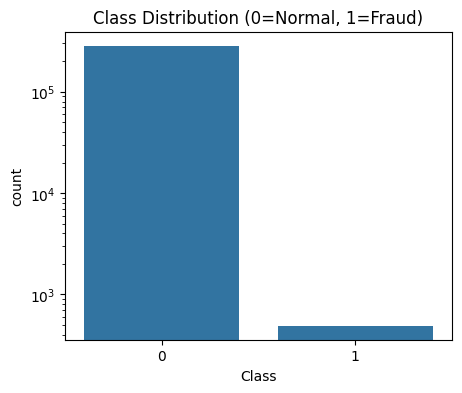

In [6]:
label_col = "Class"  # 0 = normal, 1 = fraud

class_counts = df_spark.groupBy(label_col).count().toPandas()
print(class_counts)

fraud_pct = class_counts.loc[class_counts[label_col] == 1, "count"].values[0] / class_counts["count"].sum() * 100
print(f"Fraud cases: {fraud_pct:.4f}% of total — highly imbalanced, hence an UNSUPERVISED approach.")

plt.figure(figsize=(5,4))
sns.barplot(x=label_col, y="count", data=class_counts)
plt.title("Class Distribution (0=Normal, 1=Fraud)")
plt.yscale("log")
plt.show()


In [7]:
amount_summary = df_spark.groupBy(label_col).agg(
    F.mean("Amount").alias("mean_amount"),
    F.stddev("Amount").alias("std_amount"),
    F.max("Amount").alias("max_amount")
).toPandas()
print(amount_summary)


   Class  mean_amount  std_amount  max_amount
0      1   122.211321  256.683288     2125.87
1      0    88.291022  250.105092    25691.16


## 4. Distributed Preprocessing → Model-Ready Data

Spark handles the ETL stage. We then hand off a cleaned, scaled array to the deep learning
framework — this reflects a realistic big-data-to-ML pipeline pattern.


In [8]:
df = df_spark.toPandas()  # handoff point: Spark -> Pandas/NumPy for DL training

feature_cols = [c for c in df.columns if c != label_col]
X = df[feature_cols].values
y = df[label_col].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_normal = X_scaled[y == 0]
X_train, X_val = train_test_split(X_normal, test_size=0.2, random_state=42)

print("Train (normal only):", X_train.shape, "| Val:", X_val.shape, "| Full (for testing):", X_scaled.shape)


Train (normal only): (227452, 30) | Val: (56863, 30) | Full (for testing): (284807, 30)


## 5. Shared Evaluation Function

In [9]:
def evaluate_autoencoder(model, X_all, y_all, label="Model", threshold=None, threshold_percentile=95):
    reconstructions = model.predict(X_all, verbose=0)
    mse = np.mean(np.power(X_all.reshape(X_all.shape[0], -1) - reconstructions.reshape(reconstructions.shape[0], -1), 2), axis=1)

    if threshold is None:
        threshold = np.percentile(mse, threshold_percentile)

    y_pred = (mse > threshold).astype(int)

    print(f"--- {label} ---")
    print("Threshold used:", threshold)
    print(classification_report(y_all, y_pred, digits=4))
    auc = roc_auc_score(y_all, mse)
    f1 = f1_score(y_all, y_pred)
    print(f"ROC-AUC: {auc:.4f} | F1: {f1:.4f}")

    return {"mse": mse, "y_pred": y_pred, "auc": auc, "f1": f1, "threshold": threshold}

results = {}


## 6. Iteration 1 — Baseline Dense Autoencoder

Simplest reasonable architecture. This is our baseline to beat.


In [10]:
def build_dense_autoencoder(input_dim, encoding_dim=14):
    inputs = keras.Input(shape=(input_dim,))
    x = layers.Dense(64, activation="relu")(inputs)
    x = layers.Dense(encoding_dim, activation="relu")(x)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(input_dim, activation="linear")(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer="adam", loss="mse")
    return model

input_dim = X_train.shape[1]
ae_v1 = build_dense_autoencoder(input_dim, encoding_dim=14)
ae_v1.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │         1,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,804 (22.67 KB)

 Trainable params: 5,804 (22.67 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history_v1 = ae_v1.fit(
    X_train, X_train,
    epochs=20, batch_size=256,
    validation_data=(X_val, X_val),
    shuffle=True, verbose=1
)


Epoch 1/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3904 - val_loss: 0.2099
Epoch 2/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.1657 - val_loss: 0.1355
Epoch 3/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.1248 - val_loss: 0.1116
Epoch 4/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1029 - val_loss: 0.0938
Epoch 5/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0905 - val_loss: 0.0841
Epoch 6/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0822 - val_loss: 0.0788
Epoch 7/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0761 - val_loss: 0.0731
Epoch 8/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0718 - val_loss: 0.0697
Epoch 9/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0666 - val_loss: 0.0651
Epoch 10/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0624 - val_loss: 0.0609
Epoch 11/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0596 - val_loss: 0.0669
Epoch 12/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step

In [12]:
results["v1_dense"] = evaluate_autoencoder(ae_v1, X_scaled, y, label="Iteration 1: Dense Autoencoder (95th pct threshold)")


--- Iteration 1: Dense Autoencoder (95th pct threshold) ---
Threshold used: 0.20423840323397574
              precision    recall  f1-score   support

           0     0.9997    0.9514    0.9749    284315
           1     0.0292    0.8455    0.0565       492

    accuracy                         0.9512    284807
   macro avg     0.5145    0.8985    0.5157    284807
weighted avg     0.9980    0.9512    0.9734    284807

ROC-AUC: 0.9451 | F1: 0.0565


## 7. Iteration 2 — LSTM Autoencoder (Sequence-Aware)

**Why this change:** transactions arrive as a stream over time. An LSTM autoencoder gives the
model short-term temporal context instead of treating every transaction independently — more
representative of a real streaming big-data scenario.


In [13]:
def create_sequences(data, window_size=5):
    return np.array([data[i:i+window_size] for i in range(len(data) - window_size + 1)])

WINDOW_SIZE = 5  # Default works well for this dataset. Optional: try 3 or 10 and compare for your report's iteration discussion.

X_train_seq = create_sequences(X_train, WINDOW_SIZE)
X_val_seq = create_sequences(X_val, WINDOW_SIZE)
X_all_seq = create_sequences(X_scaled, WINDOW_SIZE)
y_all_seq = y[WINDOW_SIZE-1:]

print("Train seq:", X_train_seq.shape, "| Full seq:", X_all_seq.shape)


Train seq: (227448, 5, 30) | Full seq: (284803, 5, 30)


In [14]:
def build_lstm_autoencoder(window_size, n_features, latent_dim=16):
    inputs = keras.Input(shape=(window_size, n_features))
    encoded = layers.LSTM(latent_dim, activation="relu")(inputs)
    repeated = layers.RepeatVector(window_size)(encoded)
    decoded = layers.LSTM(n_features, activation="relu", return_sequences=True)(repeated)
    model = keras.Model(inputs, decoded)
    model.compile(optimizer="adam", loss="mse")
    return model

ae_v2 = build_lstm_autoencoder(WINDOW_SIZE, X_train.shape[1], latent_dim=16)
ae_v2.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 5, 30)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 16)             │         3,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 5, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 5, 30)          │         5,640 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,648 (33.78 KB)

 Trainable params: 8,648 (33.78 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history_v2 = ae_v2.fit(
    X_train_seq, X_train_seq,
    epochs=20, batch_size=256,
    validation_data=(X_val_seq, X_val_seq),
    shuffle=True, verbose=1
)


Epoch 1/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 0.9169 - val_loss: 0.9001
Epoch 2/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - loss: 0.8872 - val_loss: 0.8883
Epoch 3/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - loss: 0.8744 - val_loss: 0.8769
Epoch 4/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 0.8620 - val_loss: 0.8643
Epoch 5/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.8539 - val_loss: 0.8550
Epoch 6/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.8466 - val_loss: 0.8536
Epoch 7/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.8436 - val_loss: 0.8520
Epoch 8/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.8447 - val_loss: 0.8414
Epoch 9/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 0.8351 - val_loss: 0.8423
Epoch 10/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.8292 - val_loss: 0.8439
Epoch 11/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.8271 - val_loss: 0.8361
Epoch 12/20
889/889 ━━━━━━━━━━

In [16]:
results["v2_lstm"] = evaluate_autoencoder(ae_v2, X_all_seq, y_all_seq, label="Iteration 2: LSTM Autoencoder (95th pct threshold)")


--- Iteration 2: LSTM Autoencoder (95th pct threshold) ---
Threshold used: 1.6055232677371407
              precision    recall  f1-score   support

           0     0.9994    0.9511    0.9747    284311
           1     0.0241    0.6972    0.0466       492

    accuracy                         0.9507    284803
   macro avg     0.5118    0.8241    0.5106    284803
weighted avg     0.9978    0.9507    0.9731    284803

ROC-AUC: 0.9112 | F1: 0.0466


## 8. Iteration 3 — LSTM + Dropout + Precision-Recall-Optimal Threshold

**Why this change:**
1. Added **Dropout** to reduce overfitting on the normal-transaction patterns.
2. Instead of an arbitrary 95th-percentile threshold, we select the threshold that **maximises F1**
   using the precision-recall curve.


In [17]:
def build_lstm_autoencoder_v3(window_size, n_features, latent_dim=16, dropout=0.2):
    inputs = keras.Input(shape=(window_size, n_features))
    x = layers.LSTM(latent_dim, activation="relu")(inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.RepeatVector(window_size)(x)
    x = layers.LSTM(n_features, activation="relu", return_sequences=True)(x)
    model = keras.Model(inputs, x)
    model.compile(optimizer="adam", loss="mse")
    return model

ae_v3 = build_lstm_autoencoder_v3(WINDOW_SIZE, X_train.shape[1], latent_dim=16, dropout=0.2)
history_v3 = ae_v3.fit(
    X_train_seq, X_train_seq,
    epochs=25, batch_size=256,
    validation_data=(X_val_seq, X_val_seq),
    shuffle=True, verbose=1
)


Epoch 1/25
889/889 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 0.9311 - val_loss: 0.9165
Epoch 2/25
889/889 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.9144 - val_loss: 0.9028
Epoch 3/25
889/889 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.9064 - val_loss: 0.8960
Epoch 4/25
889/889 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.8995 - val_loss: 0.8963
Epoch 5/25
889/889 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.8944 - val_loss: 0.8818
Epoch 6/25
889/889 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.8876 - val_loss: 0.8711
Epoch 7/25
889/889 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.8832 - val_loss: 0.8787
Epoch 8/25
889/889 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.8819 - val_loss: 0.8656
Epoch 9/25
889/889 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.8781 - val_loss: 0.8640
Epoch 10/25
889/889 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.8769 - val_loss: 0.8664
Epoch 11/25
889/889 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.8734 - val_loss: 0.8600
Epoch 12/25
889/889 ━━━━━━━━━━

In [18]:
reconstructions_v3 = ae_v3.predict(X_all_seq, verbose=0)
mse_v3 = np.mean(np.power(X_all_seq - reconstructions_v3, 2), axis=(1,2))

precisions, recalls, thresholds = precision_recall_curve(y_all_seq, mse_v3)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

print(f"F1-optimal threshold: {best_threshold:.4f} (F1={f1_scores[best_idx]:.4f})")

results["v3_lstm_dropout_optimal_threshold"] = evaluate_autoencoder(
    ae_v3, X_all_seq, y_all_seq,
    label="Iteration 3: LSTM + Dropout + F1-optimal threshold",
    threshold=best_threshold
)


F1-optimal threshold: 11.9486 (F1=0.1598)
--- Iteration 3: LSTM + Dropout + F1-optimal threshold ---
Threshold used: 11.94861287251588
              precision    recall  f1-score   support

           0     0.9986    0.9974    0.9980    284311
           1     0.1259    0.2134    0.1584       492

    accuracy                         0.9961    284803
   macro avg     0.5623    0.6054    0.5782    284803
weighted avg     0.9971    0.9961    0.9966    284803

ROC-AUC: 0.9113 | F1: 0.1584


## 9. Compare All Iterations

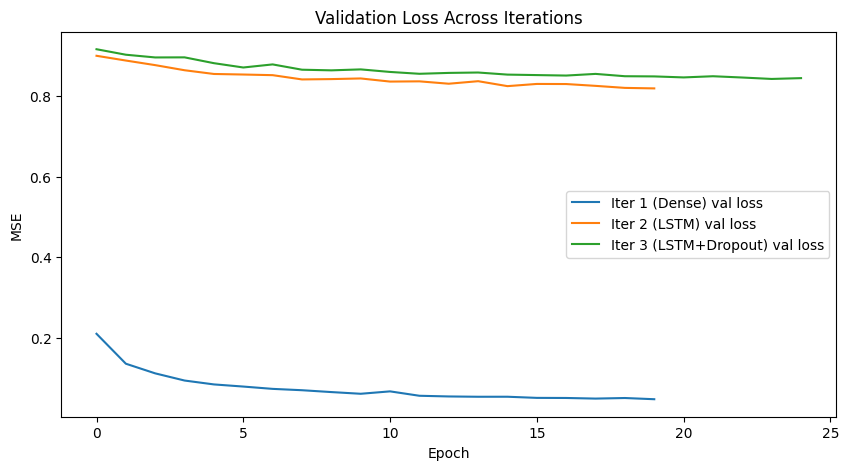

In [19]:
plt.figure(figsize=(10,5))
plt.plot(history_v1.history["val_loss"], label="Iter 1 (Dense) val loss")
plt.plot(history_v2.history["val_loss"], label="Iter 2 (LSTM) val loss")
plt.plot(history_v3.history["val_loss"], label="Iter 3 (LSTM+Dropout) val loss")
plt.legend(); plt.title("Validation Loss Across Iterations"); plt.xlabel("Epoch"); plt.ylabel("MSE")
plt.show()


                           Iteration   ROC-AUC        F1
0                           v1_dense  0.945119  0.056472
1                            v2_lstm  0.911163  0.046562
2  v3_lstm_dropout_optimal_threshold  0.911308  0.158371


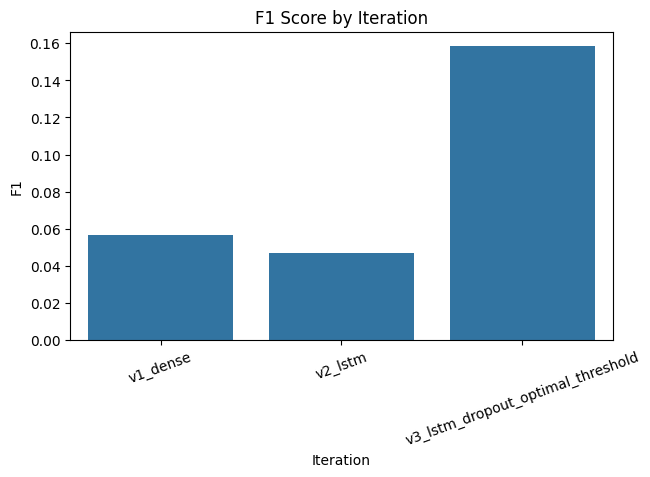

In [20]:
summary = pd.DataFrame({
    "Iteration": list(results.keys()),
    "ROC-AUC": [results[k]["auc"] for k in results],
    "F1": [results[k]["f1"] for k in results],
})
print(summary)

plt.figure(figsize=(7,4))
sns.barplot(x="Iteration", y="F1", data=summary)
plt.xticks(rotation=20)
plt.title("F1 Score by Iteration")
plt.show()


## 11. Spark Shutdown

In [21]:
spark.stop()